# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1.1

In [2]:
TAMANHO = 1000

num_bin = np.random.choice(a=(0,1), size=TAMANHO)

valor = 0
for i, dado in enumerate(num_bin):
    valor += dado*((1/2)**(i+1))    

print(valor)


0.5875450408550535


Aqui, eu gerei um vetor com zeros e ums, e depois utilizei um loop para utilizar a decomposição binária (elevando 1/2 a potências naturais) e multiplicando por cada valor do vetor (dado) e somando, para obter o número entre 0 e 1

### 1.2

In [3]:
binarizacao = (1/2)**np.arange(1,TAMANHO+1)
vetor_ultimo = binarizacao*num_bin

print(np.sum(vetor_ultimo))
print(np.sum((1/2)**np.arange(1,TAMANHO+1)*num_bin))

0.5875450408550537
0.5875450408550537


Aqui eu criei a variável "binarizacao" para criar um vetor com as potências naturais de 0.5, mas como o arange vai ate um valor antes, precisamos colocar TAMANHO+1.
Também criei o "vetor_ultimo" que multiplica, entrada por entrada, a potencia de 0.5 do vetor "binarizacao" por o vetor "num_bin", que tem valores 0 ou 1.
Por fim, somei o "vetor_ultimo" para obter valor entre 0 e 1. Preferi criar váriaveis desse jeito ao invés de colocar o print com tudo dentro de uma vez para ficar mais organizado os passos

### 1.3

(array([ 983.,  984.,  978.,  980., 1017., 1017., 1047.,  968., 1026.,
        1000.]),
 array([2.16153087e-04, 1.00186348e-01, 2.00156542e-01, 3.00126737e-01,
        4.00096931e-01, 5.00067126e-01, 6.00037320e-01, 7.00007515e-01,
        7.99977709e-01, 8.99947904e-01, 9.99918098e-01]),
 <BarContainer object of 10 artists>)

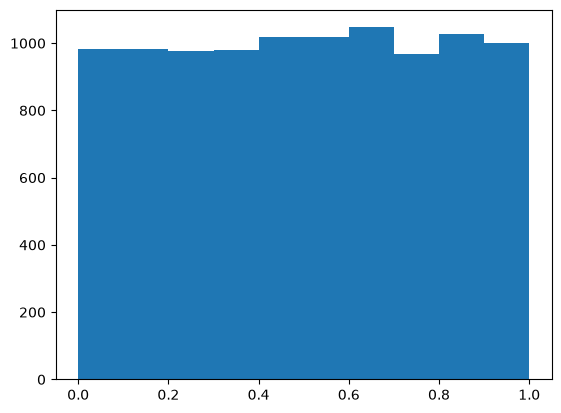

In [4]:
amostra_final = []

for i in range(10000):
    num_bin = np.random.choice(a=(0,1), size=TAMANHO)
    num = np.sum((1/2)**np.arange(1,TAMANHO+1)*num_bin)
    amostra_final.append(num)


plt.hist(amostra_final)

Aqui eu utilizei um for para gerar uma amostra de valores entre 0 e 1 e adicioná-los na lista "amostra_final", depois disso, apenas plotei um histograma da minha amostra

(array([1025.,  983., 1023., 1039.,  997.,  938.,  976.,  993., 1019.,
        1007.]),
 array([2.02794478e-05, 1.00016308e-01, 2.00012337e-01, 3.00008366e-01,
        4.00004394e-01, 5.00000423e-01, 5.99996452e-01, 6.99992481e-01,
        7.99988509e-01, 8.99984538e-01, 9.99980567e-01]),
 <BarContainer object of 10 artists>)

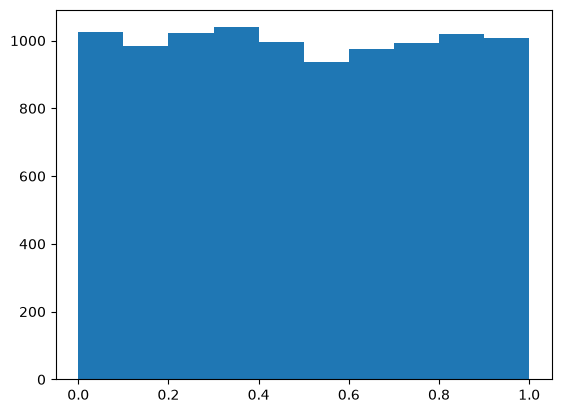

In [5]:
amostra_pela_funcao = np.random.uniform(low=0, high=1, size=10000)
plt.hist(amostra_pela_funcao)

Aqui eu só utilizei a funcao np.random.uniform e plotei o histograma. Percebe-se que os histogramas são parecidos, o que mostra que ambos os métodos geram resultados satisfatórios

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [6]:
uniforme = np.random.uniform(size=1000)

Apenas gerei uma amostra uniforme de tamanho 1000

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

### 2.1

In [7]:
prob = 0.90
D = 50
bernoulli = []

for i in range(D):
    U = np.random.uniform(low=0, high=1)
    if U > prob:
        bernoulli.append(1)
    else:
        bernoulli.append(0)

print(bernoulli)
print(np.mean(bernoulli))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.06


Aqui eu gerei uma amostra bernoulli a partir de numeros entre 0 e 1. Se o número gerado for menor que a probabilidade, consideramos sucesso, e portanto, 1. Caso contrário, se o número gerado entre 0 e 1 for maior que a probabilidade, considera-se fracasso, e portanto 0. Além disso, eu fui adicionando os valores da bernoulli em uma lista

### 2.2

In [8]:
def f(amostra,parametro):
    lista = []
    for num in amostra:
        if num < parametro:
            lista.append(1)
        else:
            lista.append(0)
    return lista
    

In [9]:
U = np.random.uniform(low=0, high=1,size=100)
amostra_bernoulli = f(U,0.8)
print(amostra_bernoulli)

[1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1]


Aqui eu basicamente fiz a mesma coisa do item anterior, mas dentro de uma função

### 2.3

In [10]:
media_amostra_bernoulli = np.mean(amostra_bernoulli)
print(media_amostra_bernoulli)

variancia_amostra_bernoulli = np.var(amostra_bernoulli)
print(variancia_amostra_bernoulli)

media_teorica_bernoulli = 0.8
variancia_teorica_bernoulli = 0.8*0.2

0.81
0.1539


Como podemos perceber, a média amostral foi 0.79, que é muito próximo da média teórica (0.8), e a variância amostral foi de 0.1659, também muito próximo da variância teórica, que é 0.16  (esses cálculos consideraram a bernoulli com parâmetro 0.8)

## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


### 3.1

In [11]:
amostra_dados = []

for i in range(100):
    U = np.random.uniform(low=0, high=1)
    if U < 1/6:
        amostra_dados.append(1)
    elif U < 2/6:
        amostra_dados.append(2)
    elif U < 3/6:
        amostra_dados.append(3)
    elif U < 4/6:
        amostra_dados.append(4)
    elif U < 5/6:
        amostra_dados.append(5)
    elif U < 1:
        amostra_dados.append(6)


print(amostra_dados) 


[2, 4, 4, 1, 4, 2, 1, 4, 2, 2, 5, 5, 5, 1, 4, 4, 1, 5, 2, 6, 4, 4, 3, 1, 3, 2, 1, 4, 6, 2, 3, 6, 4, 1, 1, 3, 5, 3, 4, 5, 2, 3, 2, 6, 5, 4, 2, 4, 2, 6, 3, 4, 3, 5, 3, 2, 2, 2, 5, 4, 6, 5, 4, 1, 5, 1, 2, 2, 1, 1, 4, 6, 4, 2, 4, 5, 2, 5, 4, 4, 6, 3, 3, 5, 4, 4, 5, 1, 6, 5, 5, 1, 5, 5, 6, 3, 1, 2, 2, 4]


Aqui eu segui a mesma lógica da bernoulli mas, o que mudou foi que eu separei o intervalo de 0 a 1 em partes iguais, de forma a ter 6 intervalos, simulando um dado (com lados 1,2,3,4,5,6)  

### 3.2

In [12]:
def gerar_dados_dado(amostra_uniforme):
    amostra_dados = []
    for i in amostra_uniforme:
        if i < 1/6:
            amostra_dados.append(1)
        elif i < 2/6:
            amostra_dados.append(2)
        elif i < 3/6:
            amostra_dados.append(3)
        elif i < 4/6:
            amostra_dados.append(4)
        elif i < 5/6:
            amostra_dados.append(5)
        else:
            amostra_dados.append(6)
    return amostra_dados

amostra = np.random.uniform(low=0,high=1,size=1000)
print(gerar_dados_dado(amostra))

[6, 1, 6, 3, 3, 5, 5, 1, 3, 5, 5, 5, 5, 2, 4, 5, 6, 1, 5, 3, 1, 4, 6, 4, 3, 2, 6, 6, 1, 6, 5, 5, 4, 6, 3, 6, 1, 5, 1, 2, 3, 3, 4, 4, 4, 3, 2, 5, 4, 2, 4, 1, 3, 4, 1, 1, 3, 2, 5, 2, 3, 6, 5, 1, 6, 5, 6, 3, 4, 1, 4, 5, 4, 4, 2, 1, 4, 4, 1, 3, 6, 3, 3, 1, 1, 6, 4, 5, 4, 6, 5, 5, 6, 1, 4, 6, 2, 5, 4, 6, 1, 5, 4, 5, 3, 4, 4, 6, 6, 1, 3, 3, 1, 2, 2, 1, 3, 4, 2, 6, 3, 6, 6, 5, 4, 1, 3, 1, 3, 5, 1, 4, 3, 2, 5, 4, 4, 4, 2, 5, 5, 2, 2, 4, 5, 5, 6, 3, 3, 3, 2, 1, 5, 1, 1, 3, 5, 5, 2, 3, 2, 2, 6, 4, 5, 2, 5, 5, 3, 2, 1, 6, 1, 5, 4, 3, 6, 6, 5, 6, 1, 5, 1, 3, 4, 4, 3, 1, 1, 2, 3, 4, 4, 5, 2, 2, 6, 3, 4, 2, 6, 1, 1, 2, 2, 2, 3, 5, 4, 1, 4, 3, 2, 1, 2, 1, 4, 4, 3, 4, 3, 2, 3, 4, 3, 4, 6, 5, 2, 6, 6, 6, 1, 4, 1, 3, 3, 2, 1, 5, 3, 4, 1, 6, 5, 4, 2, 5, 6, 4, 2, 5, 1, 6, 1, 2, 2, 6, 6, 4, 6, 3, 1, 5, 3, 5, 4, 6, 5, 4, 3, 6, 1, 1, 4, 3, 4, 3, 2, 3, 6, 1, 3, 1, 2, 1, 4, 6, 2, 1, 3, 3, 2, 5, 4, 1, 5, 2, 4, 6, 1, 5, 3, 5, 6, 2, 5, 3, 3, 2, 2, 6, 4, 6, 6, 5, 4, 1, 5, 3, 6, 3, 6, 1, 6, 4, 2, 2, 1, 4, 6, 4, 6, 

Aqui eu só segui a ideia do item anterior e criei uma função que calcular os valores do dado a partir de uma uniforme de tamanho N de dados.

### 3.3

In [13]:
amostra_uniforme = np.random.uniform(low=0,high=1,size=1000)
amostra_uniforme_6 = amostra_uniforme*6 
amostra_uniforme_arredondada = np.ceil(amostra_uniforme_6)
print(f'A amostra dos dados é\n {amostra_uniforme_arredondada}')



A amostra dos dados é
 [4. 2. 1. 4. 5. 5. 1. 2. 2. 3. 6. 6. 5. 3. 3. 3. 1. 3. 3. 6. 3. 2. 4. 6.
 2. 6. 2. 5. 5. 1. 3. 5. 3. 4. 5. 1. 1. 5. 1. 1. 6. 6. 6. 2. 3. 6. 2. 1.
 3. 5. 5. 1. 5. 4. 1. 6. 6. 6. 4. 5. 5. 6. 5. 1. 2. 6. 6. 3. 3. 5. 1. 1.
 5. 6. 1. 2. 2. 4. 1. 3. 3. 4. 4. 6. 3. 5. 6. 2. 2. 5. 6. 6. 6. 5. 4. 1.
 6. 6. 6. 4. 1. 5. 4. 3. 3. 2. 3. 2. 1. 3. 5. 2. 4. 6. 2. 4. 5. 6. 4. 5.
 3. 1. 6. 6. 5. 2. 1. 4. 6. 6. 4. 5. 1. 1. 5. 1. 3. 6. 4. 5. 1. 6. 2. 4.
 4. 2. 6. 6. 2. 3. 1. 5. 6. 1. 4. 3. 3. 2. 5. 6. 1. 2. 2. 4. 5. 5. 1. 3.
 3. 3. 5. 3. 2. 4. 6. 3. 3. 2. 5. 4. 2. 4. 1. 1. 4. 6. 5. 2. 3. 2. 1. 1.
 3. 5. 4. 4. 5. 4. 5. 6. 2. 1. 6. 4. 2. 4. 2. 6. 2. 2. 6. 5. 2. 5. 3. 3.
 5. 5. 2. 5. 1. 4. 5. 6. 6. 1. 1. 6. 4. 1. 2. 4. 2. 1. 4. 3. 2. 6. 3. 2.
 1. 2. 4. 3. 1. 2. 2. 6. 4. 1. 4. 2. 4. 5. 3. 6. 4. 5. 2. 2. 6. 6. 4. 2.
 1. 3. 5. 4. 3. 5. 1. 6. 4. 5. 6. 3. 6. 6. 6. 1. 1. 2. 1. 4. 4. 1. 5. 6.
 3. 5. 6. 3. 3. 3. 2. 6. 6. 3. 3. 2. 4. 5. 5. 2. 6. 4. 6. 5. 2. 5. 6. 4.
 4. 4. 4. 1. 4. 1. 1. 1. 5. 

### 3.4

In [14]:
faces, frequencia_absoluta =  np.unique(amostra_uniforme_arredondada,return_counts=True)
frequencia_relativa = frequencia_absoluta/1000
frequencia_relativa

array([0.159, 0.16 , 0.168, 0.166, 0.168, 0.179])

As frequências relativas estão entre 0.183 e 0.149, o que é bem perto do valor teórico, que é 1/6 (0,166666...)

### 3.5

In [15]:
dados = np.arange(1,7)

media_amostral = np.mean(amostra_uniforme_arredondada)
variancia_amostral = np.var(amostra_uniforme_arredondada)

media_teorica = np.mean(dados)
Ex2 = np.sum(dados**2)/6
Ex_ao_quadrado = media_teorica**2
var = Ex2 - Ex_ao_quadrado


print(f'A média teórica é: {media_teorica}. Já a média amostral é {media_amostral}')
print(f'A variância teórica é: {var}. Já a variância amostral é: {variancia_amostral}')

A média teórica é: 3.5. Já a média amostral é 3.561
A variância teórica é: 2.916666666666666. Já a variância amostral é: 2.9302789999999996


Aqui eu apenas calculei a média e a variância teórica e amostral, e elas são muito parecidas, como esperado.

### 3.6

In [16]:
def gerar_dados_dado_viciado(amostra_uniforme):
    amostra_dados = []
    for i in amostra_uniforme:
        if i < 5/100:
            amostra_dados.append(1)
        elif i < 15/100:
            amostra_dados.append(2)
        elif i < 30/100:
            amostra_dados.append(3)
        elif i < 50/100:
            amostra_dados.append(4)
        elif i < 70/100:
            amostra_dados.append(5)
        else:
            amostra_dados.append(6)
    return amostra_dados


In [17]:
amostra_normal = np.random.uniform(low=0,high=1,size=10)
amostra_viciada = gerar_dados_dado_viciado(amostra_normal)
print(amostra_viciada)

[3, 6, 4, 6, 5, 5, 6, 5, 3, 6]


Aqui eu apenas repeti o processo para o dado viciado

## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


### 4.1

In [18]:
# aprender a fazer com loop depois
amostra_de_binomiais = []
prob = 0.5
bernoulli = []
binomial = 0

for j in range(10):
    for i in range(100):
        U = np.random.uniform(low=0, high=1)
        if U > prob:
            bernoulli.append(1)
            binomial += 1
        else:
            bernoulli.append(0)
    amostra_de_binomiais.append(binomial)

print(binomial)
print(amostra_de_binomiais)

518
[53, 110, 163, 214, 262, 315, 364, 417, 463, 518]


In [19]:
# jeito facil de fazer uma binomial
amostra_binomial = []
n = 1000 # parametro da binomial
p = 0.5
N = 100 # nro de elementos da amostra
for i in range(N):
    uniforme = np.random.uniform(size=n)
    binomial = np.sum(uniforme < p)
    amostra_binomial.append(binomial)



In [20]:
amostra_binomial

[np.int64(517),
 np.int64(491),
 np.int64(519),
 np.int64(495),
 np.int64(503),
 np.int64(477),
 np.int64(500),
 np.int64(477),
 np.int64(487),
 np.int64(514),
 np.int64(527),
 np.int64(492),
 np.int64(507),
 np.int64(495),
 np.int64(520),
 np.int64(456),
 np.int64(509),
 np.int64(521),
 np.int64(514),
 np.int64(512),
 np.int64(512),
 np.int64(515),
 np.int64(524),
 np.int64(502),
 np.int64(484),
 np.int64(492),
 np.int64(472),
 np.int64(492),
 np.int64(498),
 np.int64(504),
 np.int64(519),
 np.int64(507),
 np.int64(496),
 np.int64(498),
 np.int64(539),
 np.int64(505),
 np.int64(514),
 np.int64(502),
 np.int64(485),
 np.int64(481),
 np.int64(501),
 np.int64(488),
 np.int64(505),
 np.int64(495),
 np.int64(483),
 np.int64(503),
 np.int64(500),
 np.int64(490),
 np.int64(487),
 np.int64(503),
 np.int64(502),
 np.int64(497),
 np.int64(474),
 np.int64(511),
 np.int64(500),
 np.int64(504),
 np.int64(509),
 np.int64(500),
 np.int64(506),
 np.int64(473),
 np.int64(476),
 np.int64(501),
 np.int6

In [21]:
len(amostra_binomial)

100

Aqui eu gerei uma amostra de binomiais utilizando um loop para gerar bernoullis (n bernoullis, ou então uma binomial com parâmetro n), gerar uma binomial, e assim adicionar a minha amostra, de tamanho N

### 4.2

In [22]:
media_amostral = np.mean(amostra_binomial)
variancia_amostral = np.var(amostra_binomial)
media_teorica = n*p
variancia_teorica = n*p*(1-p)

print(f' Média teórica: {media_teorica} e média amostral: {media_amostral}')
print(f' Variância teórica: {variancia_teorica} e variância amostral: {variancia_amostral}')

 Média teórica: 500.0 e média amostral: 500.95
 Variância teórica: 250.0 e variância amostral: 244.34750000000003


Aqui eu apenas calculei a média e a variância teórica e amostral, e como esperado, elas são muito próximas

### 4.3

(array([  4.,  32.,  72., 134., 223., 227., 171.,  90.,  36.,  11.]),
 array([35., 38., 41., 44., 47., 50., 53., 56., 59., 62., 65.]),
 <BarContainer object of 10 artists>)

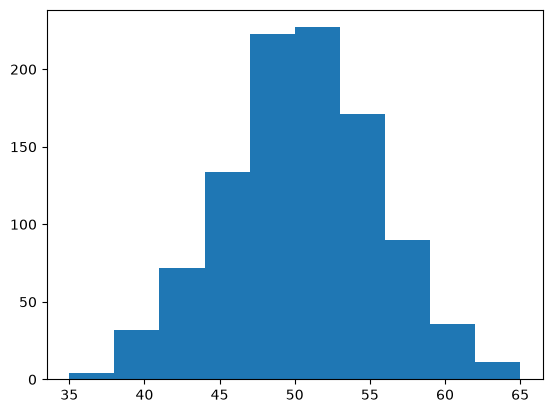

In [23]:
funcao_binomial = np.random.binomial(100,0.5, size= 1000)
plt.hist(funcao_binomial)

Aqui eu apenas usei a função "random.binomial" para gerar uma amostra de binomiais

## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

In [24]:
multinomial = []
n = 20
for i in range(n):
    U = np.random.uniform(low=0, high=1)
    if U < 1/10:
        multinomial.append(1)
    elif U < 3/10:
        multinomial.append(2)
    elif U < 6/10:
        multinomial.append(3)
    elif U < 1:
        multinomial.append(4)
print(multinomial)

[4, 4, 4, 2, 4, 2, 4, 3, 3, 3, 4, 2, 2, 2, 4, 1, 3, 3, 4, 3]


Aqui eu gerei apenas uma multinomial, com n lançamentos, de um dado de 4 lados viciado

In [25]:
np.unique(multinomial,return_counts=True)

(array([1, 2, 3, 4]), array([1, 5, 6, 8]))

Aqui eu apenas usei a funcao "unique" para conseguir ver o nro de casos com 2, 3 e 4

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

In [26]:
nro_de_multinomiais = 100 # tamanho da amostra 
amostra_multinomiais = []
n = 100 # nro de lancamentos de cada multinomial
for j in range(nro_de_multinomiais):
    multinomial = []
    for i in range(n):
        U = np.random.uniform(low=0, high=1)
        if U < 1/10:
            multinomial.append(1)
        elif U < 3/10:
            multinomial.append(2)
        elif U < 6/10:
            multinomial.append(3)
        else:
            multinomial.append(4)
    amostra_multinomiais.append(np.unique(multinomial, return_counts=True)[1])

In [27]:
nomes_linhas = [f'Amostra {i+1}' for i in range(len(amostra_multinomiais))]

df = pd.DataFrame(
    amostra_multinomiais, 
    columns = ['Face 1', 'Face 2', 'Face 3', 'Face 4'],
    index = nomes_linhas
)
df

,Face 1,Face 2,Face 3,Face 4
Amostra 1,12,19,28,41
Amostra 2,9,21,30,40
Amostra 3,13,21,31,35
Amostra 4,11,13,36,40
Amostra 5,6,26,32,36
...,...,...,...,...
Amostra 96,10,23,29,38
Amostra 97,10,22,30,38
Amostra 98,7,14,33,46
Amostra 99,7,16,32,45


Aqui eu gerei uma amostra de 100 multinomiais, sendo que cada multinomial tem como parametro n=100 (pensei em fazer com os dois parametros multiplos de 10, pois quando eu for somar cada caso (como no código abaixo) darem números mais "intuitivos", como para x=4 eu ter aproximadamente 4000 observações)

In [28]:
somas = np.sum(amostra_multinomiais,axis=0)
somas

array([ 991, 2008, 3003, 3998])

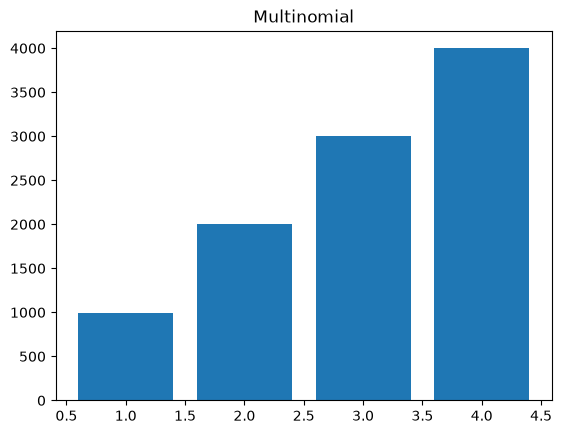

In [29]:
plt.bar([1,2,3,4], somas)
plt.title("Multinomial")
plt.show()

Aqui eu plotei a multinomial em um gráfico de barras para visualizar as frequências absolutas da distribuição

In [30]:
# funcao_vetorizada = np.vetorize(funcao)
# ensina a funcao a trabalhar com vetor

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

In [31]:
media_teorica_1 = 0.1*n
media_teorica_2 = 0.2*n
media_teorica_3 = 0.3*n
media_teorica_4 = 0.4*n

print(f'As médias teóricas para cada Xi, i = 1,2,3,4, são, respectivamente: {media_teorica_1}, {media_teorica_2}, {media_teorica_3} e {media_teorica_4}. ')

As médias teóricas para cada Xi, i = 1,2,3,4, são, respectivamente: 10.0, 20.0, 30.0 e 40.0. 


In [32]:
media_amostral_1 = somas[0]/100
media_amostral_2 = somas[1]/100
media_amostral_3 = somas[2]/100
media_amostral_4 = somas[3]/100

print(f'As médias amostrais para cada Xi, i = 1,2,3,4, são, respectivamente: {media_amostral_1}, {media_amostral_2}, {media_amostral_3} e {media_amostral_4}. ')

As médias amostrais para cada Xi, i = 1,2,3,4, são, respectivamente: 9.91, 20.08, 30.03 e 39.98. 


Aqui eu calculei as médias amostrais e teóricas de cada Xi, e como pode ser percebido, são muito proximas, como esperado

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

In [33]:
amostra_funcao_multinomial = np.random.multinomial(n=100, pvals=(0.1,0.2,0.3,0.4), size=100)

df = pd.DataFrame(
    amostra_funcao_multinomial, 
    columns = ['Face 1', 'Face 2', 'Face 3', 'Face 4'],
    index = nomes_linhas
)
df['Total'] = df[['Face 1', 'Face 2', 'Face 3', 'Face 4']].sum(axis=1)
df

,Face 1,Face 2,Face 3,Face 4,Total
Amostra 1,15,21,29,35,100
Amostra 2,9,21,30,40,100
Amostra 3,10,21,37,32,100
Amostra 4,7,19,31,43,100
Amostra 5,13,20,36,31,100
...,...,...,...,...,...
Amostra 96,8,26,32,34,100
Amostra 97,10,16,27,47,100
Amostra 98,9,23,28,40,100
Amostra 99,10,16,37,37,100


In [34]:
somas_funcao = np.sum(amostra_funcao_multinomial,axis=0)
somas_funcao

array([ 983, 2063, 3003, 3951])

As amostras geradas pelos dois métodos são muito parecidas, pois seguem a mesma distribuição com os mesmos parâmetros

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

In [35]:
# para a amostra usando np.random.multinomial
n = 100
contagens = 0
for amostra in amostra_funcao_multinomial:
    if np.sum(amostra) == 100:
        contagens += 1
print(contagens)

100


In [36]:
# para a amostra usando loops
n = 100
contagens = 0
for amostra in amostra_multinomiais:
    if np.sum(amostra) == 100:
        contagens += 1
print(f'{contagens} multinomiais da amostra de 100 multinomiais tem 100 lancamentos')

100 multinomiais da amostra de 100 multinomiais tem 100 lancamentos


Como todas as multinomiais tem como soma dos lancamentos das k faces igual a 100, sim, são iguai a n, que também é 100

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

In [37]:
probs = [0.1,0.2,0.3,0.4]

for prob in probs:
    variancia_teorica = 100*(prob)*(1-prob)
    print(f'Variância teórica da face {prob*10}: {variancia_teorica}')

Variância teórica da face 1.0: 9.0
Variância teórica da face 2.0: 16.0
Variância teórica da face 3.0: 21.0
Variância teórica da face 4.0: 24.0


In [38]:
amostra_np = np.array(amostra_multinomiais) # Para transformar de lista para um vetor no numpy

In [39]:
for i in range(4):
    soma_quadrados = np.sum(amostra_np[:,i] ** 2)
    var = (soma_quadrados - (somas[i]**2)/100)/99
    print(f'A variância amostral da face {i} é: {var}')

A variância amostral da face 0 é: 9.638282828282833
A variância amostral da face 1 é: 21.528888888888893
A variância amostral da face 2 é: 20.130404040404077
A variância amostral da face 3 é: 26.060202020201938


Aqui eu apenas utilizei um loop para calcular as variâncias tanto amostrais quanto teóricas, e percebe-se que elas estão próximas

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.

In [40]:
covariancia_teorica = (-1)*(100*0.1*0.2)
covariancia_amostral = np.cov(amostra_np[:,0], amostra_np[:,1])[0,1]

print(f'A covariância teórica é {covariancia_teorica}, e a covariância amostral é {covariancia_amostral}')

A covariância teórica é -2.0, e a covariância amostral é -2.730101010101011


Aqui eu calculei a covariância teórica e amostral, que também se mostram próximas. O sinal negativo da covâriancia se da pois há uma relação inversamente proporcional entre o número de vezes que apareceu a face 1 e o número de vezes que apareceu a face 2, já que, em n realizações, quanto mais aparece uma determinada face, menos aparece a outra